# 02 — EDA: Fiscal Hawkishness Signal (v6 — EPU-style, winsorised)

Signal formula: `signal_t = (H_t − D_t) / P_t`, winsorised at 2.5/97.5 pct before z-scoring.  
Primary BVAR column: `net_hawkish_z` in `data/processed/bvar_signal.csv`.  
Dictionary: 61 hawkish + 46 dovish terms. Fiscal filter: `fiscal_topic_prob ≥ 0.15`.


## 1. Setup & data loading

In [13]:
%matplotlib inline
import os, re, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

_ROOT     = os.path.abspath(os.path.join(os.getcwd(), ".."))
INTERIM   = os.path.join(_ROOT, "data", "interim")
PROCESSED = os.path.join(_ROOT, "data", "processed")
TABLES    = os.path.join(_ROOT, "outputs", "tables")

PRES_ORDER  = ["Macri", "AF", "Milei"]
PRES_COLORS = {"Macri":"#2196F3", "AF":"#4CAF50", "Milei":"#FF5722"}
PRES_LABELS = {"Macri":"Macri (2015–2019)", "AF":"A. Fernández (2019–2023)", "Milei":"Milei (2023–2026)"}
plt.rcParams.update({"figure.dpi":130,"axes.spines.top":False,"axes.spines.right":False})

monthly = pd.read_csv(os.path.join(INTERIM,   "monthly_signal.csv"))
bvar    = pd.read_csv(os.path.join(PROCESSED, "bvar_signal.csv"))
para    = pd.read_csv(os.path.join(INTERIM,   "paragraphs_scored.csv"))
speech  = pd.read_csv(os.path.join(INTERIM,   "speeches_scored.csv"))
h_hits  = pd.read_csv(os.path.join(TABLES,    "term_hits_hawkish.csv"))
d_hits  = pd.read_csv(os.path.join(TABLES,    "term_hits_dovish.csv"))

monthly["ym_dt"] = pd.to_datetime(monthly["year_month"])

print(f"monthly_signal  : {len(monthly)} rows | NaN net_hawkish_z: {monthly['net_hawkish_z'].isna().sum()}")
print(f"paragraphs      : {len(para):,} | fiscal: {para['is_fiscal'].sum():,}")
print(f"speeches        : {len(speech):,}")
print(f"hawkish hits CSV: {len(h_hits):,} rows | dovish: {len(d_hits):,}")


monthly_signal  : 127 rows | NaN net_hawkish_z: 2
paragraphs      : 16,197 | fiscal: 3,980
speeches        : 1,498
hawkish hits CSV: 989 rows | dovish: 341


## 2. Coverage — fiscal paragraph composition by president

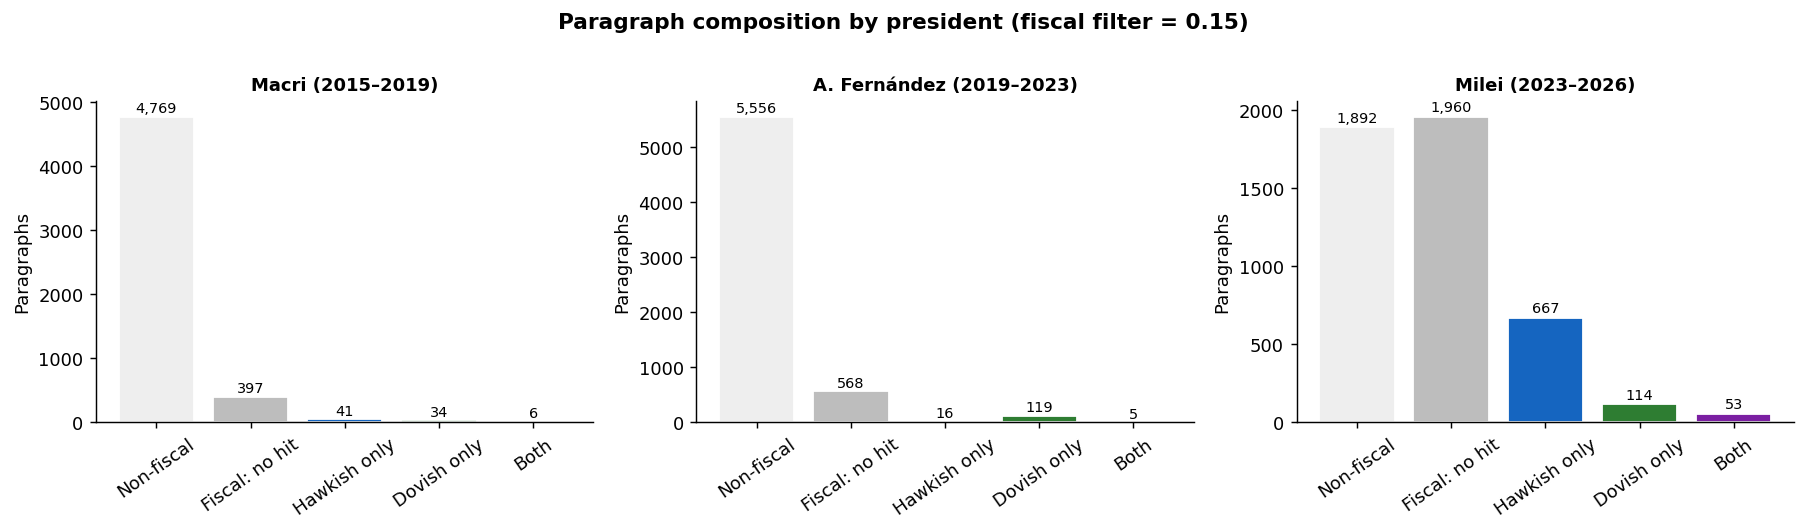

President    Total   Fiscal   Fiscal%   H-hit   D-hit   (H-D)/P
Macri       5,247      478      9.1%      47      40     0.015
AF          6,264      708     11.3%      21     124    -0.145
Milei       4,686    2,794     59.6%     720     167     0.198


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, pres in zip(axes, PRES_ORDER):
    g = para[para["president"]==pres]
    f = g[g["is_fiscal"]].copy()
    P = len(f)
    n_nf    = len(g) - P
    n_nohit = int(((f["has_hawkish"]==0) & (f["has_dovish"]==0)).sum())
    n_honly = int(((f["has_hawkish"]==1) & (f["has_dovish"]==0)).sum())
    n_donly = int(((f["has_hawkish"]==0) & (f["has_dovish"]==1)).sum())
    n_both  = int(((f["has_hawkish"]==1) & (f["has_dovish"]==1)).sum())

    labels = ["Non-fiscal","Fiscal: no hit","Hawkish only","Dovish only","Both"]
    values = [n_nf, n_nohit, n_honly, n_donly, n_both]
    colors_ = ["#EEEEEE","#BDBDBD","#1565C0","#2E7D32","#7B1FA2"]
    bars = ax.bar(labels, values, color=colors_, edgecolor="white")
    ax.set_title(PRES_LABELS[pres], fontsize=10, fontweight="bold")
    ax.set_ylabel("Paragraphs"); ax.tick_params(axis="x", rotation=35)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
                f"{val:,}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Paragraph composition by president (fiscal filter = 0.15)", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

print(f"{'President':8s}  {'Total':>7s}  {'Fiscal':>7s}  {'Fiscal%':>8s}  {'H-hit':>6s}  {'D-hit':>6s}  {'(H-D)/P':>8s}")
for pres in PRES_ORDER:
    g = para[para["president"]==pres]; f = g[g["is_fiscal"]]
    P=len(f); H=int((f["has_hawkish"]==1).sum()); D=int((f["has_dovish"]==1).sum())
    print(f"{pres:8s}  {len(g):>7,}  {P:>7,}  {P/len(g)*100:>7.1f}%  {H:>6,}  {D:>6,}  {(H-D)/P if P else 0:>8.3f}")


## 3. Fiscal paragraphs per month (P_t) — denominator stability

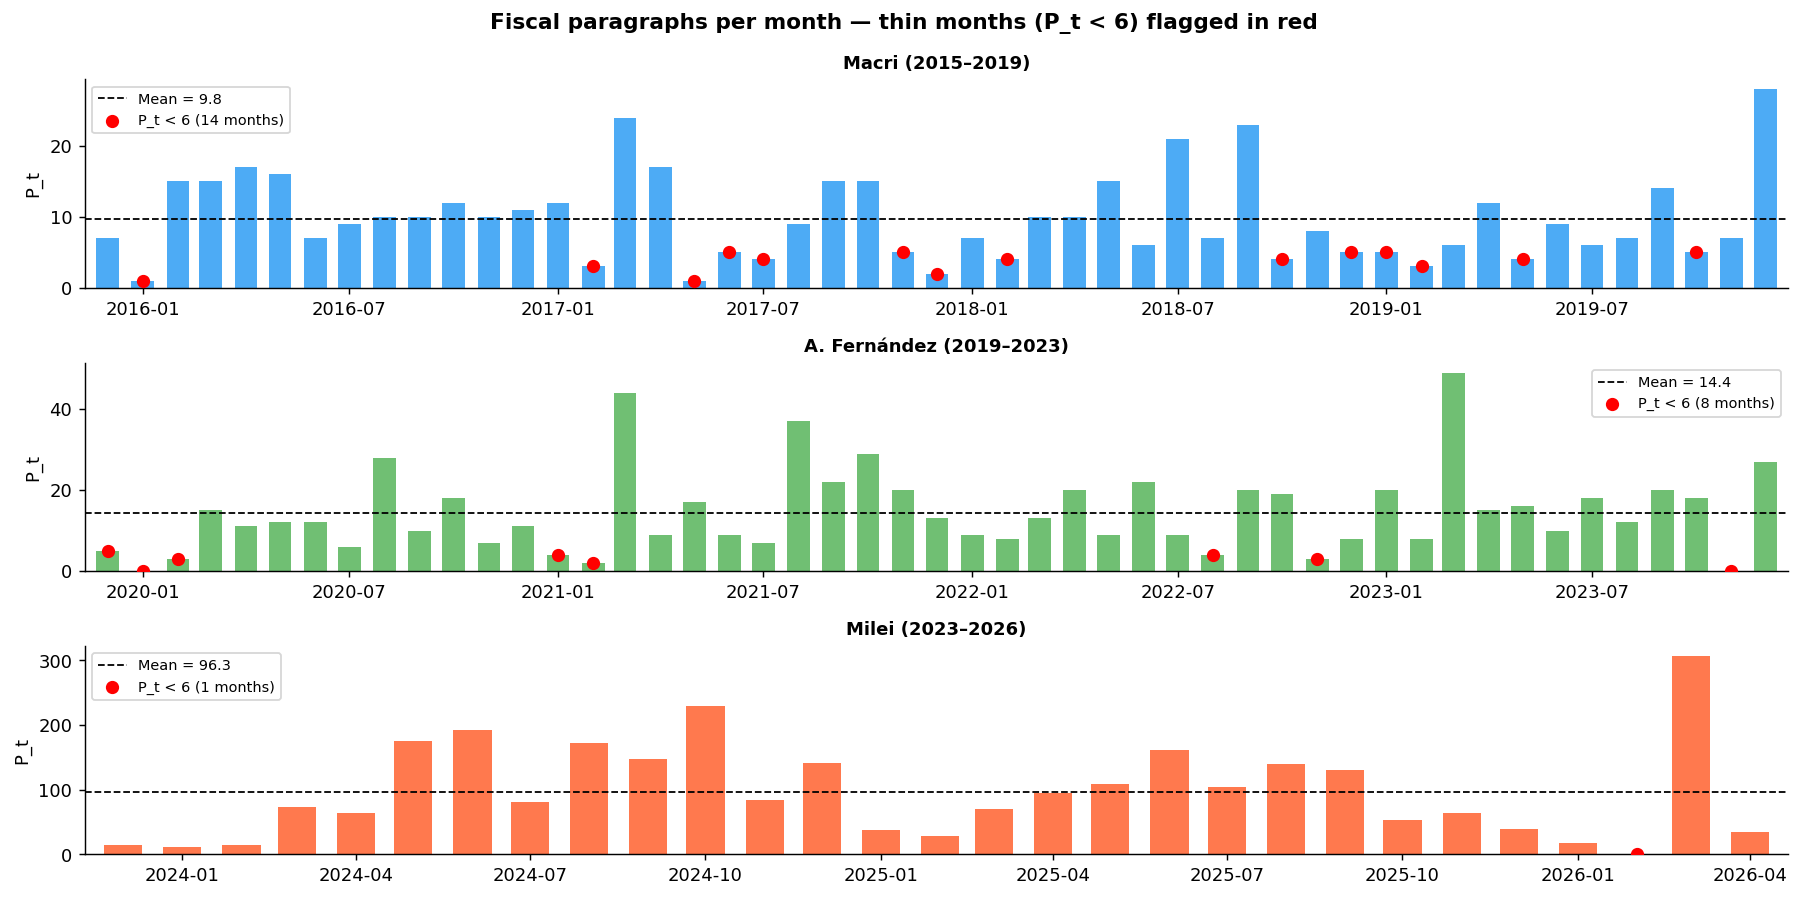

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=False)
for ax, pres in zip(axes, PRES_ORDER):
    g = monthly[monthly["president"]==pres].sort_values("ym_dt")
    ax.bar(g["ym_dt"], g["n_fiscal_paras"], color=PRES_COLORS[pres], alpha=0.8, width=20)
    ax.axhline(g["n_fiscal_paras"].mean(), color="black", lw=1, ls="--",
               label=f"Mean = {g['n_fiscal_paras'].mean():.1f}")
    # Flag thin months
    thin = g[g["n_fiscal_paras"] < 6]
    ax.scatter(thin["ym_dt"], thin["n_fiscal_paras"], color="red", zorder=5, s=40,
               label=f"P_t < 6 ({len(thin)} months)")
    ax.set_title(PRES_LABELS[pres], fontsize=10, fontweight="bold")
    ax.set_ylabel("P_t"); ax.legend(fontsize=8)
    ax.set_xlim(g["ym_dt"].min()-pd.Timedelta(days=20), g["ym_dt"].max()+pd.Timedelta(days=20))

plt.suptitle("Fiscal paragraphs per month — thin months (P_t < 6) flagged in red", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


## 4. Time series — net_hawkish_z (primary BVAR input)

`net_hawkish_z` is the winsorised signal (raw clipped at 2.5/97.5 pct before z-scoring).  
`net_hawkish_z_raw` is the unwinsorised version for comparison.


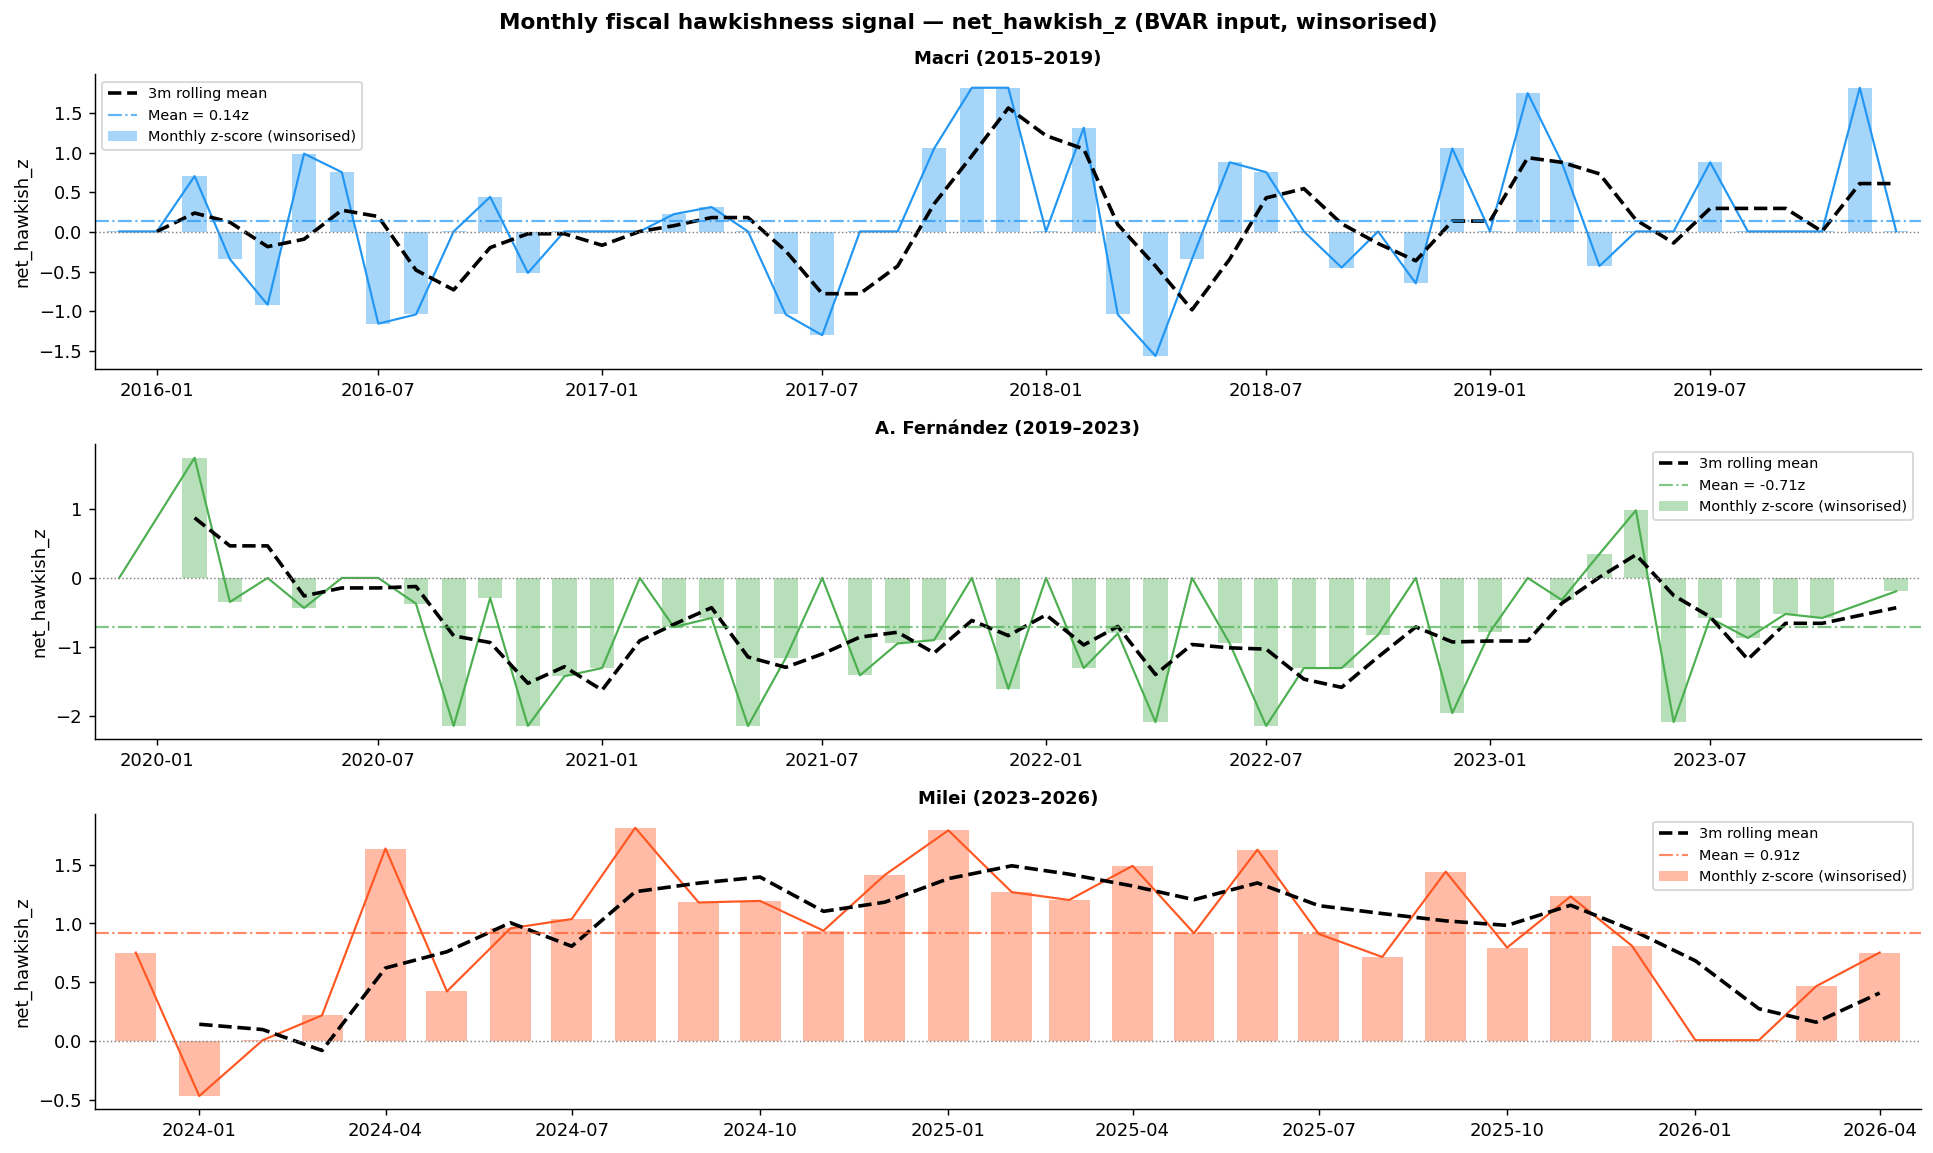

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=False)
for ax, pres in zip(axes, PRES_ORDER):
    g = monthly[monthly["president"]==pres].sort_values("ym_dt")
    g_v = g.dropna(subset=["net_hawkish_z"])
    ax.bar(g["ym_dt"], g["net_hawkish_z"].fillna(0), color=PRES_COLORS[pres],
           alpha=0.4, width=20, label="Monthly z-score (winsorised)")
    ax.plot(g_v["ym_dt"], g_v["net_hawkish_z"], color=PRES_COLORS[pres], lw=1.2)
    rolling = g_v.set_index("ym_dt")["net_hawkish_z"].rolling(3, min_periods=2).mean()
    ax.plot(rolling.index, rolling.values, color="black", lw=2, ls="--", label="3m rolling mean")
    ax.axhline(0, color="grey", lw=0.8, ls=":")
    ax.axhline(g_v["net_hawkish_z"].mean(), color=PRES_COLORS[pres], lw=1.2, ls="-.",
               alpha=0.7, label=f"Mean = {g_v['net_hawkish_z'].mean():.2f}z")
    ax.set_title(PRES_LABELS[pres], fontsize=10, fontweight="bold")
    ax.set_ylabel("net_hawkish_z"); ax.legend(fontsize=8)
    ax.set_xlim(g["ym_dt"].min()-pd.Timedelta(days=20), g["ym_dt"].max()+pd.Timedelta(days=20))

plt.suptitle("Monthly fiscal hawkishness signal — net_hawkish_z (BVAR input, winsorised)", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


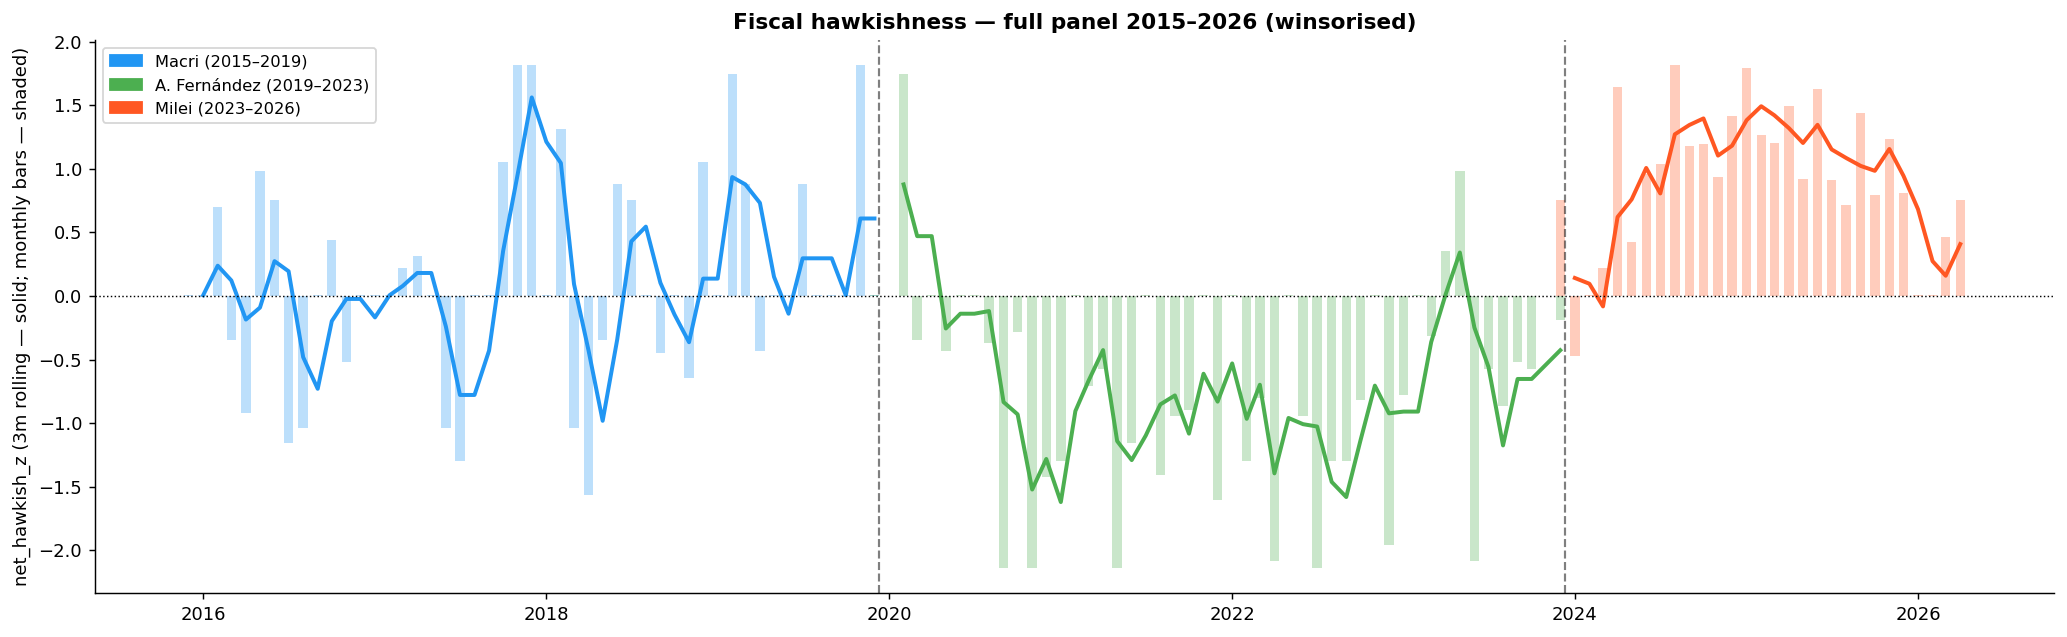

In [17]:
# ── Full panel ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
for pres in PRES_ORDER:
    g = monthly[monthly["president"]==pres].sort_values("ym_dt")
    g_v = g.dropna(subset=["net_hawkish_z"])
    ax.bar(g["ym_dt"], g["net_hawkish_z"].fillna(0), color=PRES_COLORS[pres], alpha=0.3, width=20)
    rolling = g_v.set_index("ym_dt")["net_hawkish_z"].rolling(3, min_periods=2).mean()
    ax.plot(rolling.index, rolling.values, color=PRES_COLORS[pres], lw=2.2, label=PRES_LABELS[pres])

ax.axhline(0, color="black", lw=0.8, ls=":")
for dt in ["2019-12-10","2023-12-10"]:
    ax.axvline(pd.Timestamp(dt), color="black", lw=1.2, ls="--", alpha=0.5)
ax.set_ylabel("net_hawkish_z (3m rolling — solid; monthly bars — shaded)")
ax.set_title("Fiscal hawkishness — full panel 2015–2026 (winsorised)", fontsize=12, fontweight="bold")
ax.legend(handles=[Patch(color=PRES_COLORS[p], label=PRES_LABELS[p]) for p in PRES_ORDER], fontsize=9)
plt.tight_layout(); plt.show()


## 5. Winsorisation audit — what changed?

Winsorising clips `net_hawkish` at the 2.5th/97.5th percentiles before z-scoring.  
This prevents thin Macri months (P_t=2–5) from producing +2.4–2.9z spikes that dominate the BVAR.


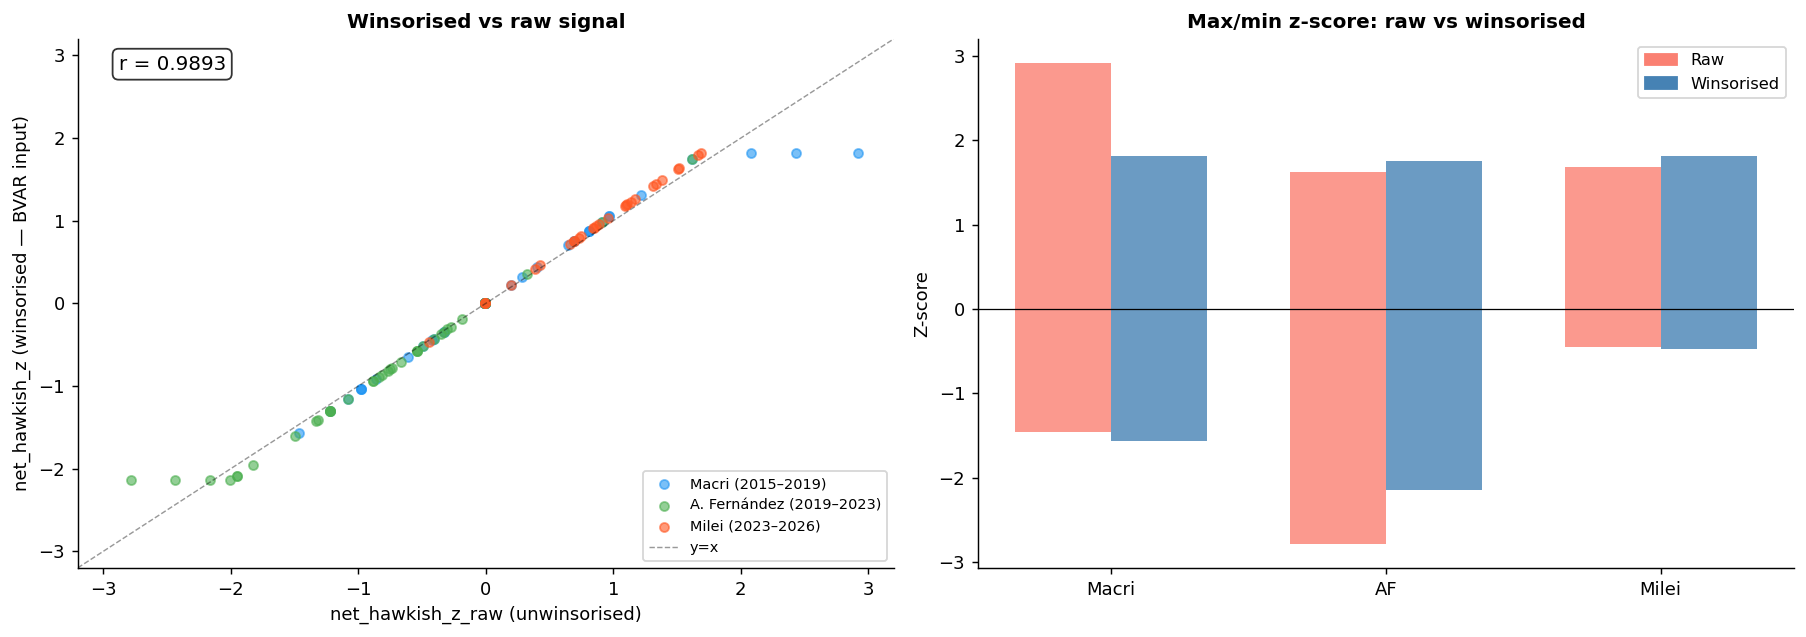

President    Raw max   Wins max    Raw min   Wins min         r
Macri          2.92       1.82      -1.46      -1.56    0.9780
AF             1.62       1.75      -2.78      -2.14    0.9900
Milei          1.68       1.82      -0.44      -0.47    1.0000

Overall r(wins, raw): 0.9893 — only tails affected


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter winsorised vs raw
ax = axes[0]
valid = monthly.dropna(subset=["net_hawkish_z","net_hawkish_z_raw"])
for pres in PRES_ORDER:
    g = valid[valid["president"]==pres]
    ax.scatter(g["net_hawkish_z_raw"], g["net_hawkish_z"], c=PRES_COLORS[pres],
               alpha=0.6, s=25, label=PRES_LABELS[pres])

lims = [-3.2, 3.2]
ax.plot(lims, lims, "k--", lw=0.8, alpha=0.4, label="y=x")
# Show clip bounds
lo_raw = monthly["net_hawkish"].quantile(0.025)
hi_raw = monthly["net_hawkish"].quantile(0.975)
r = valid["net_hawkish_z"].corr(valid["net_hawkish_z_raw"])
ax.text(0.05, 0.97, f"r = {r:.4f}", transform=ax.transAxes, va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
ax.set_xlabel("net_hawkish_z_raw (unwinsorised)")
ax.set_ylabel("net_hawkish_z (winsorised — BVAR input)")
ax.set_title("Winsorised vs raw signal", fontsize=11, fontweight="bold")
ax.legend(fontsize=8); ax.set_xlim(lims); ax.set_ylim(lims)

# Right: bar chart of max z by president, before/after
ax2 = axes[1]
metrics = []
for pres in PRES_ORDER:
    g = valid[valid["president"]==pres]
    metrics.append({
        "pres": pres,
        "raw_max": g["net_hawkish_z_raw"].max(),
        "wins_max": g["net_hawkish_z"].max(),
        "raw_min": g["net_hawkish_z_raw"].min(),
        "wins_min": g["net_hawkish_z"].min(),
    })

x = np.arange(len(PRES_ORDER))
w = 0.35
ax2.bar(x - w/2, [m["raw_max"] for m in metrics],  w, label="Raw max",  color="salmon",    alpha=0.8)
ax2.bar(x + w/2, [m["wins_max"] for m in metrics], w, label="Wins max", color="steelblue", alpha=0.8)
ax2.bar(x - w/2, [m["raw_min"] for m in metrics],  w, color="salmon",    alpha=0.8, label="Raw min")
ax2.bar(x + w/2, [m["wins_min"] for m in metrics], w, color="steelblue", alpha=0.8, label="Wins min")
ax2.axhline(0, color="black", lw=0.7)
ax2.set_xticks(x); ax2.set_xticklabels(PRES_ORDER)
ax2.set_ylabel("Z-score"); ax2.set_title("Max/min z-score: raw vs winsorised", fontsize=11, fontweight="bold")
handles = [Patch(color="salmon", label="Raw"), Patch(color="steelblue", label="Winsorised")]
ax2.legend(handles=handles, fontsize=9)

plt.tight_layout(); plt.show()

# Table
print(f"{'President':8s}  {'Raw max':>9s}  {'Wins max':>9s}  {'Raw min':>9s}  {'Wins min':>9s}  {'r':>8s}")
for pres in PRES_ORDER:
    g = valid[valid["president"]==pres]
    r_ = g["net_hawkish_z"].corr(g["net_hawkish_z_raw"])
    print(f"{pres:8s}  {g['net_hawkish_z_raw'].max():>9.2f}  {g['net_hawkish_z'].max():>9.2f}  "
          f"{g['net_hawkish_z_raw'].min():>9.2f}  {g['net_hawkish_z'].min():>9.2f}  {r_:>8.4f}")
print(f"\nOverall r(wins, raw): {r:.4f} — only tails affected")


## 6. Score distributions by president

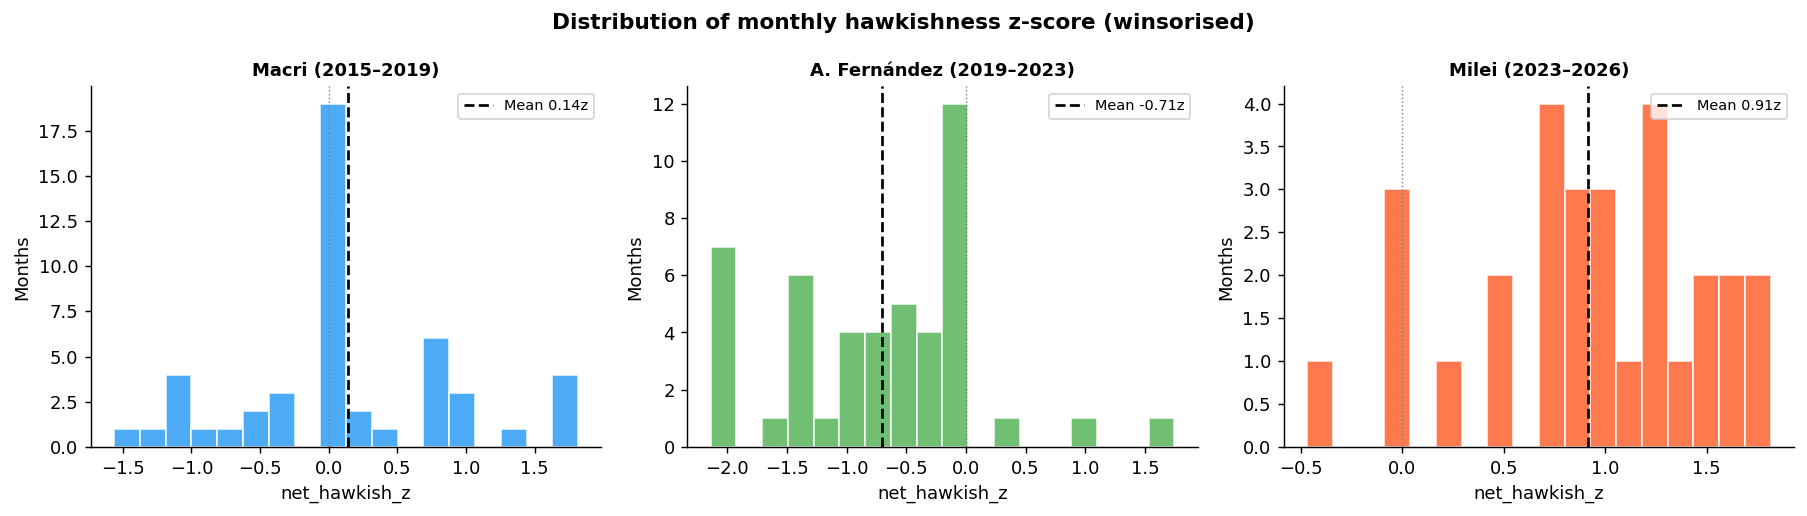

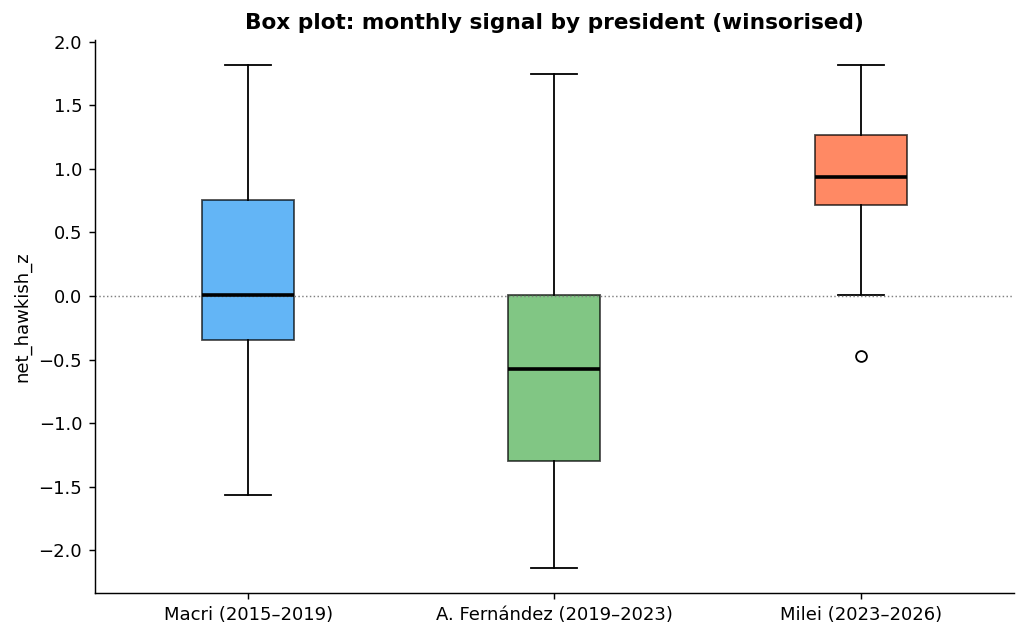

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, pres in zip(axes, PRES_ORDER):
    g = monthly[monthly["president"]==pres]["net_hawkish_z"].dropna()
    ax.hist(g, bins=18, color=PRES_COLORS[pres], alpha=0.8, edgecolor="white")
    ax.axvline(g.mean(), color="black", lw=1.5, ls="--", label=f"Mean {g.mean():.2f}z")
    ax.axvline(0, color="grey", lw=0.8, ls=":")
    ax.set_title(PRES_LABELS[pres], fontsize=10, fontweight="bold")
    ax.set_xlabel("net_hawkish_z"); ax.set_ylabel("Months"); ax.legend(fontsize=8)
plt.suptitle("Distribution of monthly hawkishness z-score (winsorised)", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
data_ = [monthly[monthly["president"]==p]["net_hawkish_z"].dropna().values for p in PRES_ORDER]
bp = ax.boxplot(data_, patch_artist=True, medianprops=dict(color="black", lw=2))
for patch, pres in zip(bp["boxes"], PRES_ORDER):
    patch.set_facecolor(PRES_COLORS[pres]); patch.set_alpha(0.7)
ax.set_xticklabels([PRES_LABELS[p] for p in PRES_ORDER])
ax.axhline(0, color="grey", lw=0.8, ls=":")
ax.set_ylabel("net_hawkish_z")
ax.set_title("Box plot: monthly signal by president (winsorised)", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


## 7. Hawkish / dovish components — H_t and D_t over time

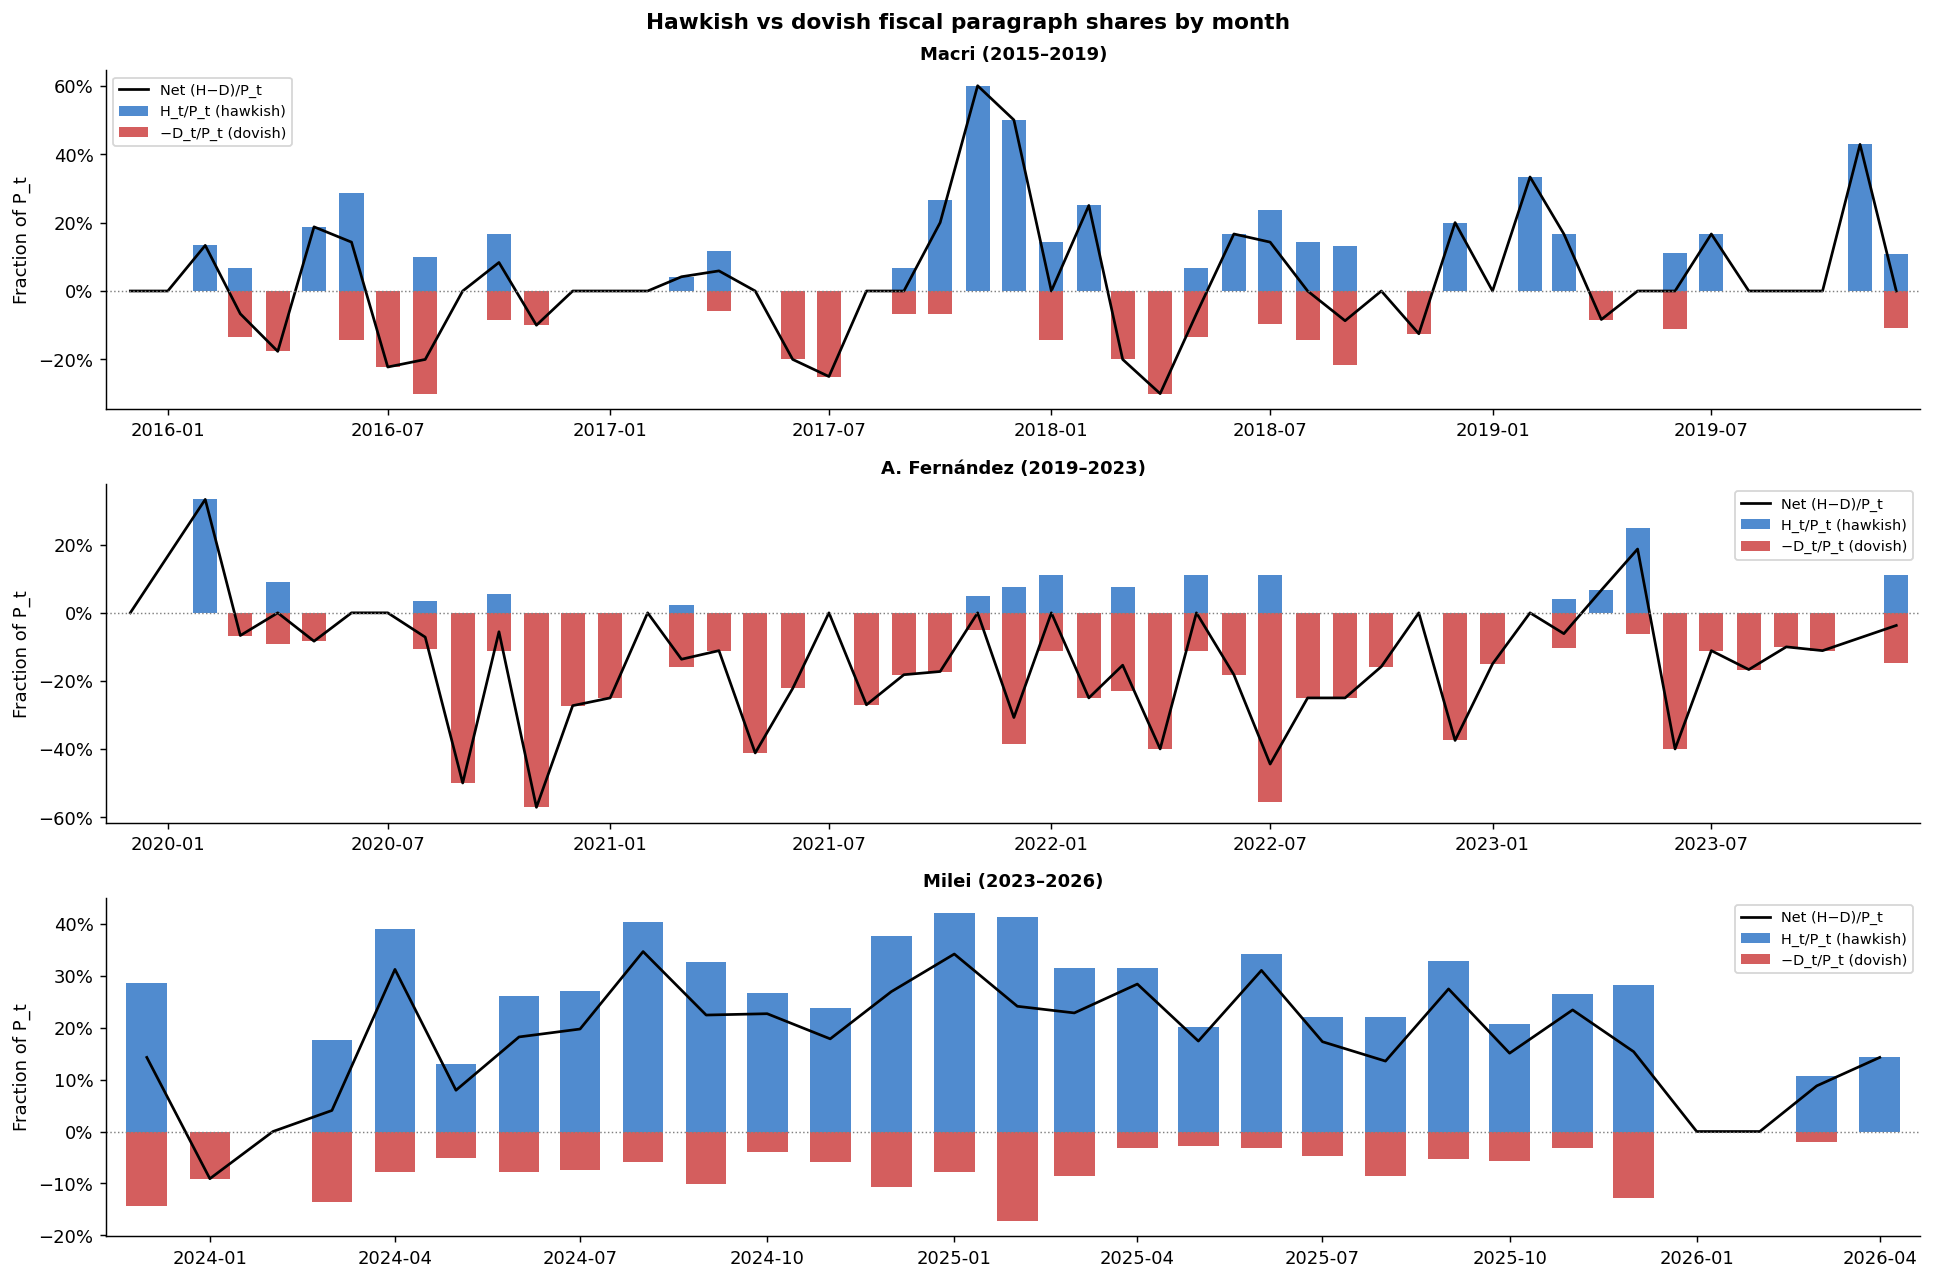

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=False)
for ax, pres in zip(axes, PRES_ORDER):
    g = monthly[monthly["president"]==pres].sort_values("ym_dt")
    g = g[g["n_fiscal_paras"]>0]
    P = g["n_fiscal_paras"]
    H_s =  g["H_t"] / P
    D_s = -g["D_t"] / P
    ax.bar(g["ym_dt"], H_s, width=20, color="#1565C0", alpha=0.75, label="H_t/P_t (hawkish)")
    ax.bar(g["ym_dt"], D_s, width=20, color="#C62828", alpha=0.75, label="−D_t/P_t (dovish)")
    ax.plot(g["ym_dt"], H_s + D_s, color="black", lw=1.5, label="Net (H−D)/P_t")
    ax.axhline(0, color="grey", lw=0.8, ls=":")
    ax.set_title(PRES_LABELS[pres], fontsize=10, fontweight="bold")
    ax.set_ylabel("Fraction of P_t"); ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_xlim(g["ym_dt"].min()-pd.Timedelta(days=20), g["ym_dt"].max()+pd.Timedelta(days=20))
plt.suptitle("Hawkish vs dovish fiscal paragraph shares by month", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


## 8. Term hit analysis — which terms fire and for whom?

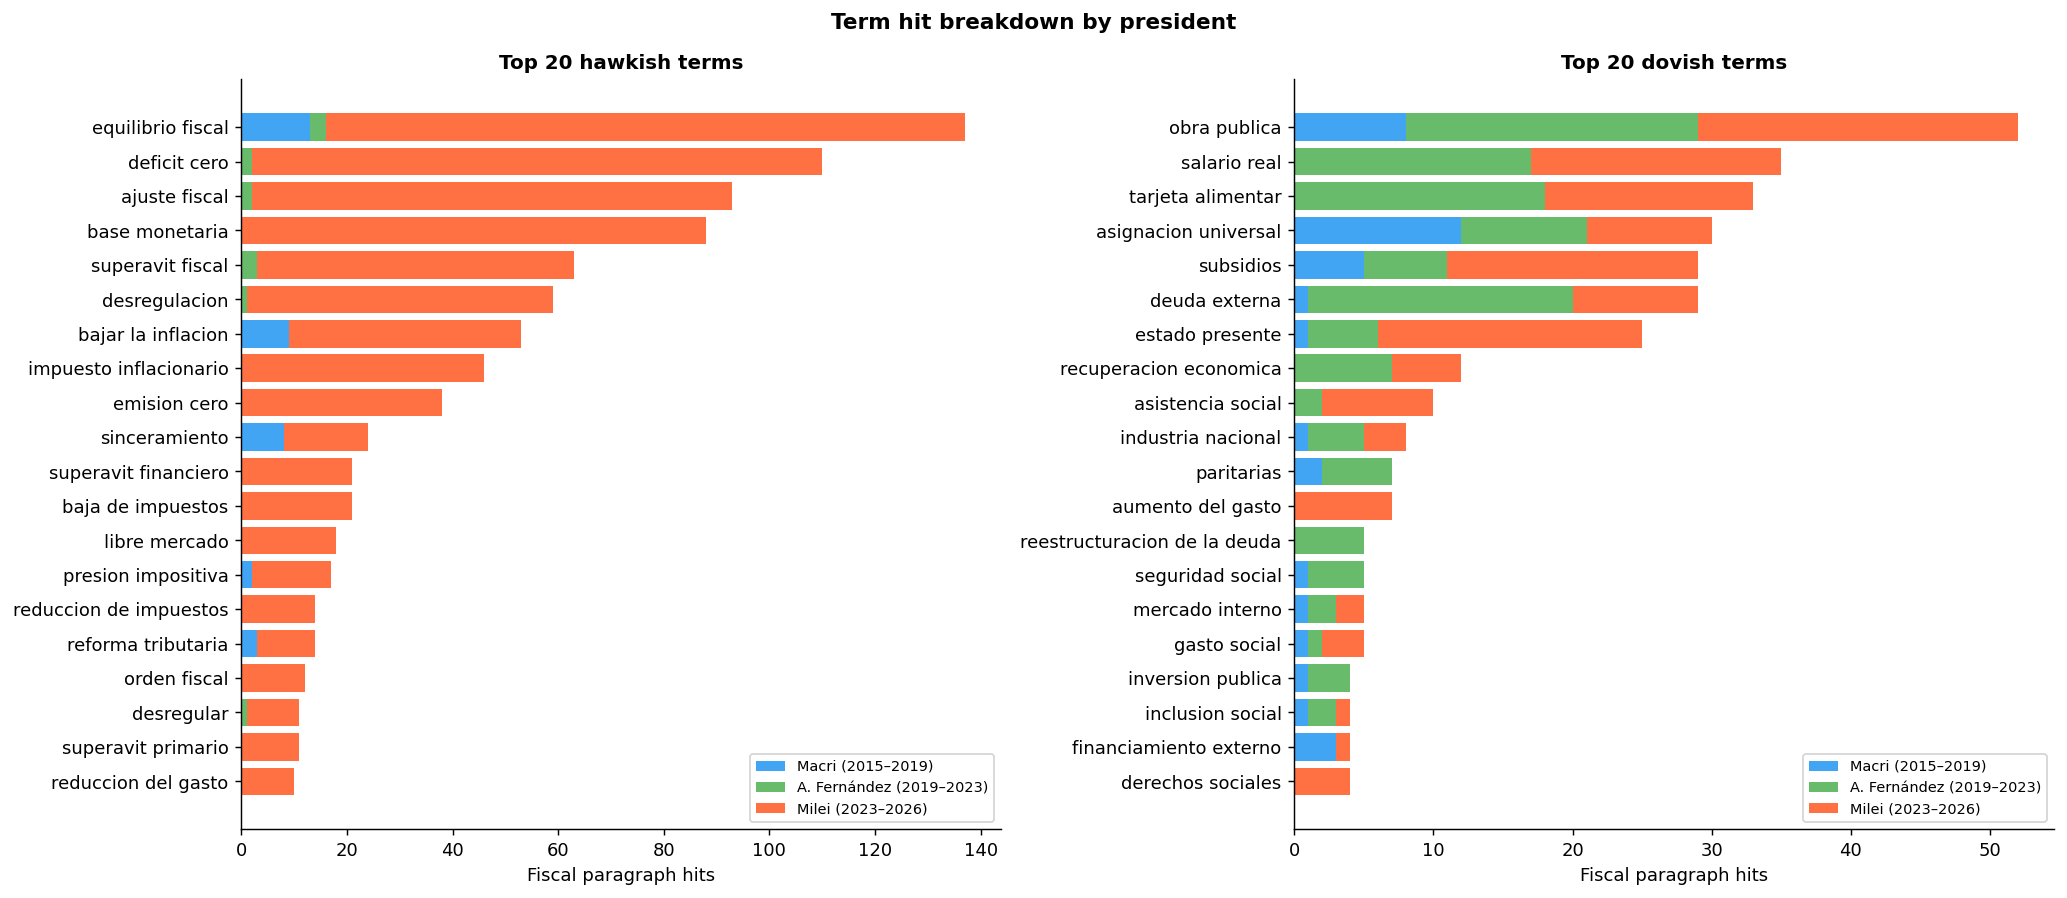

In [21]:
# ── Top hawkish terms ─────────────────────────────────────────────────────────
top_n = 20
h_counts = h_hits.groupby(["term","president"]).size().reset_index(name="n")
h_totals = h_counts.groupby("term")["n"].sum().nlargest(top_n).index
h_wide   = h_counts[h_counts["term"].isin(h_totals)].pivot_table(
    index="term", columns="president", values="n", fill_value=0).reindex(columns=PRES_ORDER)
h_wide   = h_wide.loc[h_wide.sum(axis=1).sort_values(ascending=True).index]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
bottom = np.zeros(len(h_wide))
for pres in PRES_ORDER:
    vals = h_wide[pres].values if pres in h_wide else np.zeros(len(h_wide))
    axes[0].barh(h_wide.index, vals, left=bottom, color=PRES_COLORS[pres], alpha=0.85, label=PRES_LABELS[pres])
    bottom += vals
axes[0].set_xlabel("Fiscal paragraph hits"); axes[0].set_title(f"Top {top_n} hawkish terms", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=8)

d_counts = d_hits.groupby(["term","president"]).size().reset_index(name="n")
d_totals = d_counts.groupby("term")["n"].sum().nlargest(top_n).index
d_wide   = d_counts[d_counts["term"].isin(d_totals)].pivot_table(
    index="term", columns="president", values="n", fill_value=0).reindex(columns=PRES_ORDER)
d_wide   = d_wide.loc[d_wide.sum(axis=1).sort_values(ascending=True).index]

bottom = np.zeros(len(d_wide))
for pres in PRES_ORDER:
    vals = d_wide[pres].values if pres in d_wide else np.zeros(len(d_wide))
    axes[1].barh(d_wide.index, vals, left=bottom, color=PRES_COLORS[pres], alpha=0.85, label=PRES_LABELS[pres])
    bottom += vals
axes[1].set_xlabel("Fiscal paragraph hits"); axes[1].set_title(f"Top {top_n} dovish terms", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=8)

plt.suptitle("Term hit breakdown by president", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


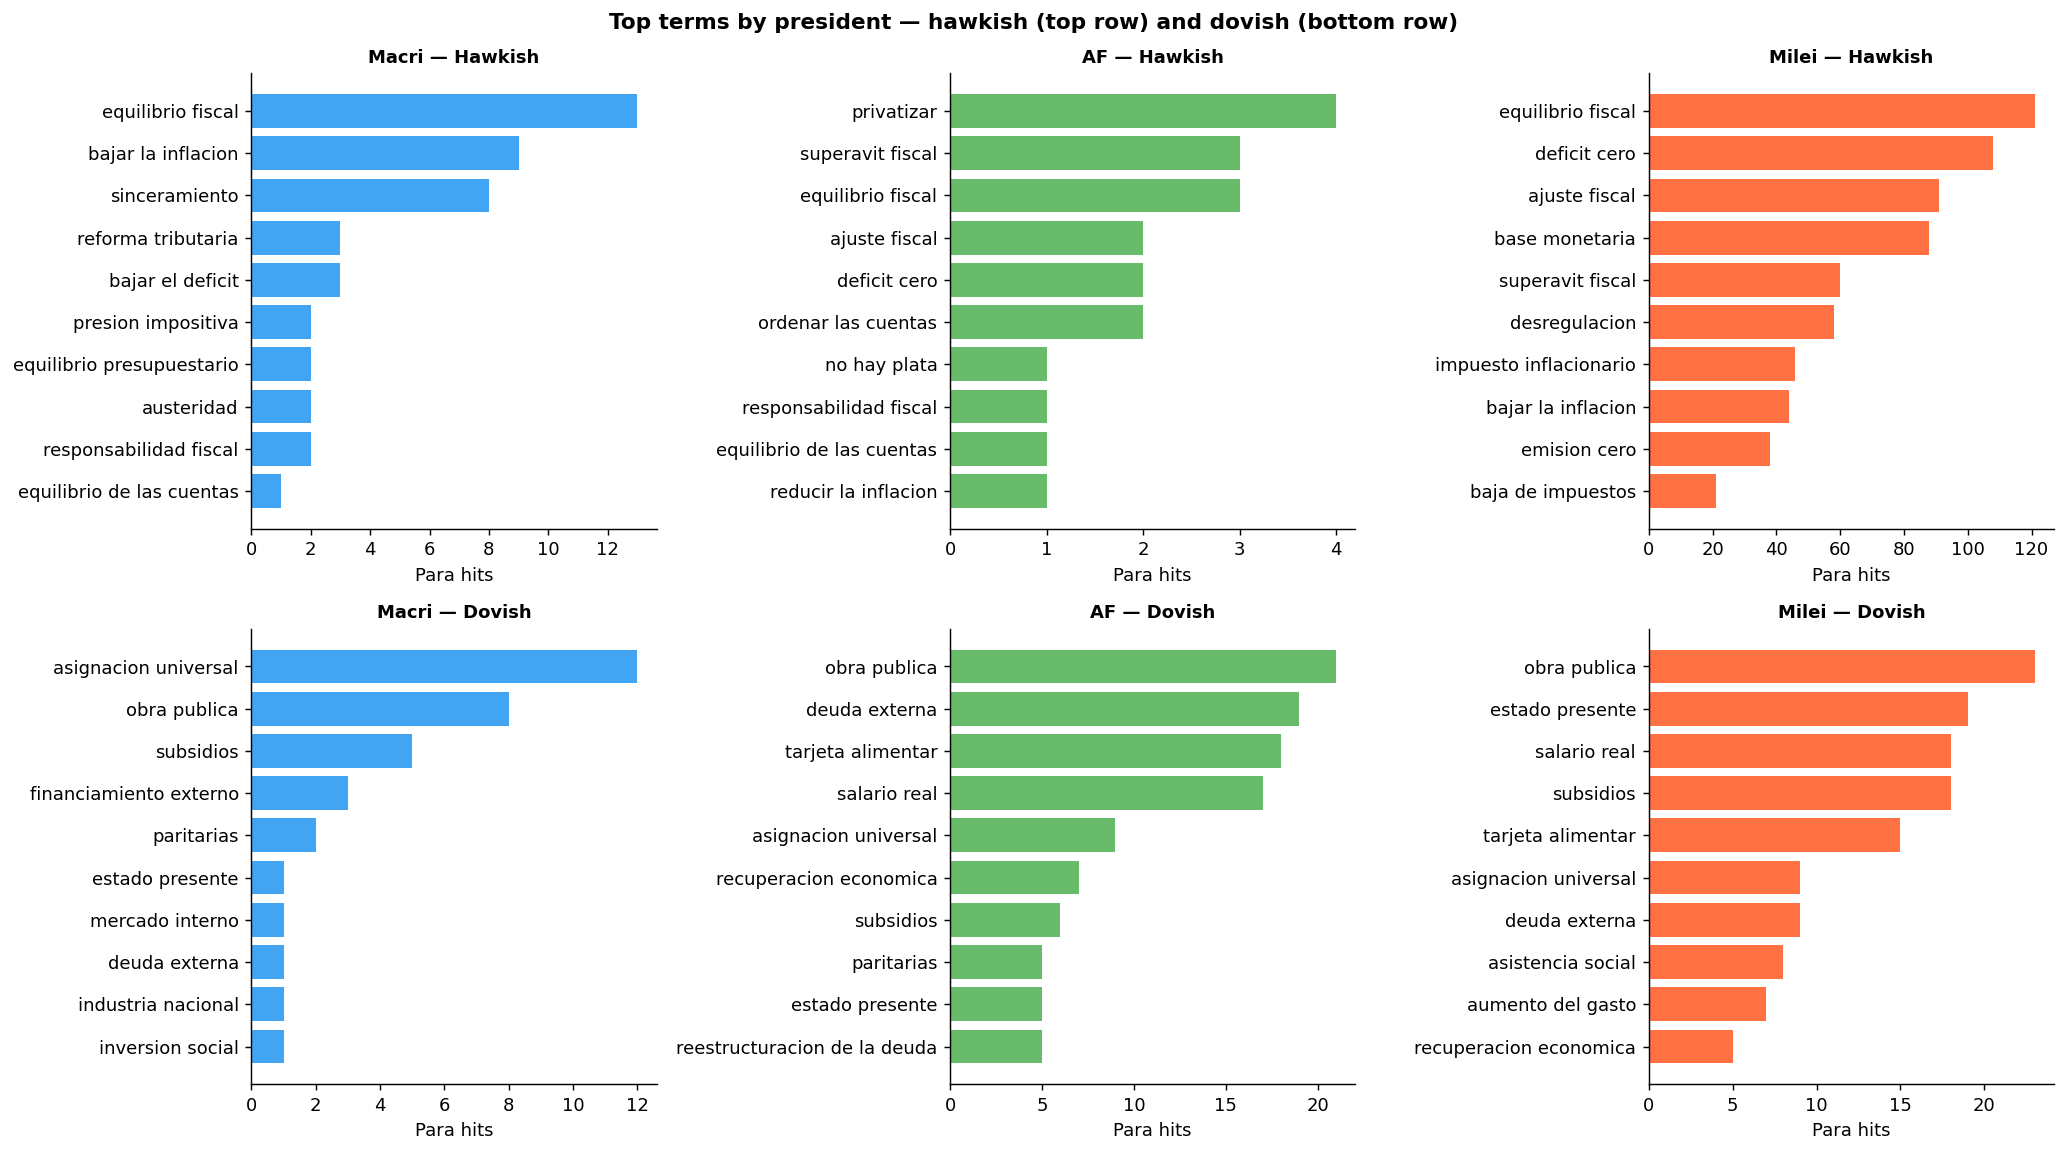

In [22]:
# Per-president top terms
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, pres in enumerate(PRES_ORDER):
    top_h = h_hits[h_hits["president"]==pres]["term"].value_counts().head(10)
    axes[0,i].barh(top_h.index[::-1], top_h.values[::-1], color=PRES_COLORS[pres], alpha=0.85)
    axes[0,i].set_title(f"{pres} — Hawkish", fontsize=10, fontweight="bold")
    axes[0,i].set_xlabel("Para hits")

    top_d = d_hits[d_hits["president"]==pres]["term"].value_counts().head(10)
    axes[1,i].barh(top_d.index[::-1], top_d.values[::-1], color=PRES_COLORS[pres], alpha=0.85)
    axes[1,i].set_title(f"{pres} — Dovish", fontsize=10, fontweight="bold")
    axes[1,i].set_xlabel("Para hits")

plt.suptitle("Top terms by president — hawkish (top row) and dovish (bottom row)", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


## 9. LDA fiscal filter calibration

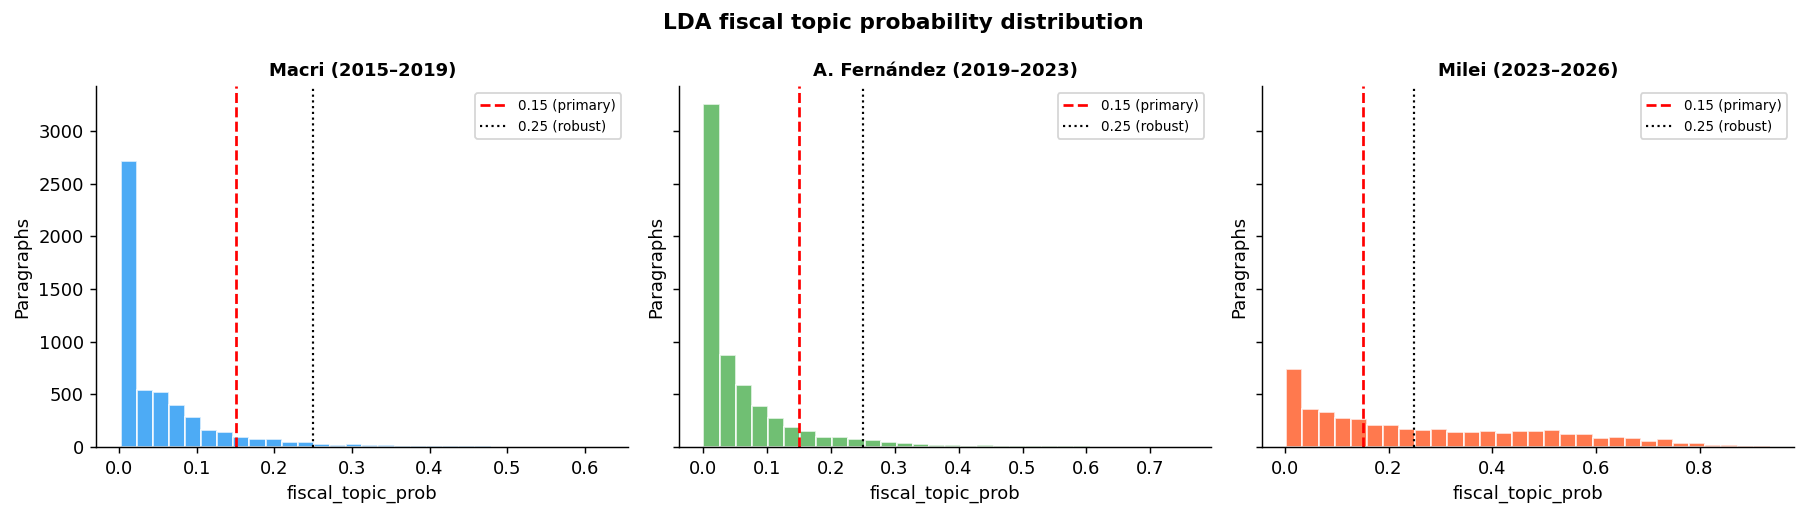

── Hit rate by fiscal_topic_prob band ───────────────────────────────────
  [0.00,0.10): 10,910 paras  hit%=  4.6%
  [0.10,0.15):  1,307 paras  hit%= 10.5%
  [0.15,0.20):    794 paras  hit%= 14.0%
  [0.20,0.25):    585 paras  hit%= 16.6%
  [0.25,0.35):    799 paras  hit%= 21.0%
  [0.35,1.01):  1,802 paras  hit%= 37.7%


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, pres in zip(axes, PRES_ORDER):
    g = para[para["president"]==pres]
    ax.hist(g["fiscal_topic_prob"], bins=30, color=PRES_COLORS[pres], alpha=0.8, edgecolor="white")
    ax.axvline(0.15, color="red",   lw=1.5, ls="--", label="0.15 (primary)")
    ax.axvline(0.25, color="black", lw=1.2, ls=":",  label="0.25 (robust)")
    ax.set_title(PRES_LABELS[pres], fontsize=10, fontweight="bold")
    ax.set_xlabel("fiscal_topic_prob"); ax.set_ylabel("Paragraphs"); ax.legend(fontsize=7.5)
plt.suptitle("LDA fiscal topic probability distribution", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

print("── Hit rate by fiscal_topic_prob band ───────────────────────────────────")
for lo, hi in [(0.00,0.10),(0.10,0.15),(0.15,0.20),(0.20,0.25),(0.25,0.35),(0.35,1.01)]:
    g = para[(para["fiscal_topic_prob"]>=lo)&(para["fiscal_topic_prob"]<hi)]
    if len(g)==0: continue
    hit = (g["has_hawkish"]|g["has_dovish"]).sum()
    print(f"  [{lo:.2f},{hi:.2f}): {len(g):>6,} paras  hit%={hit/len(g)*100:>5.1f}%")


## 10. Robustness — P_t vs N_t denominator

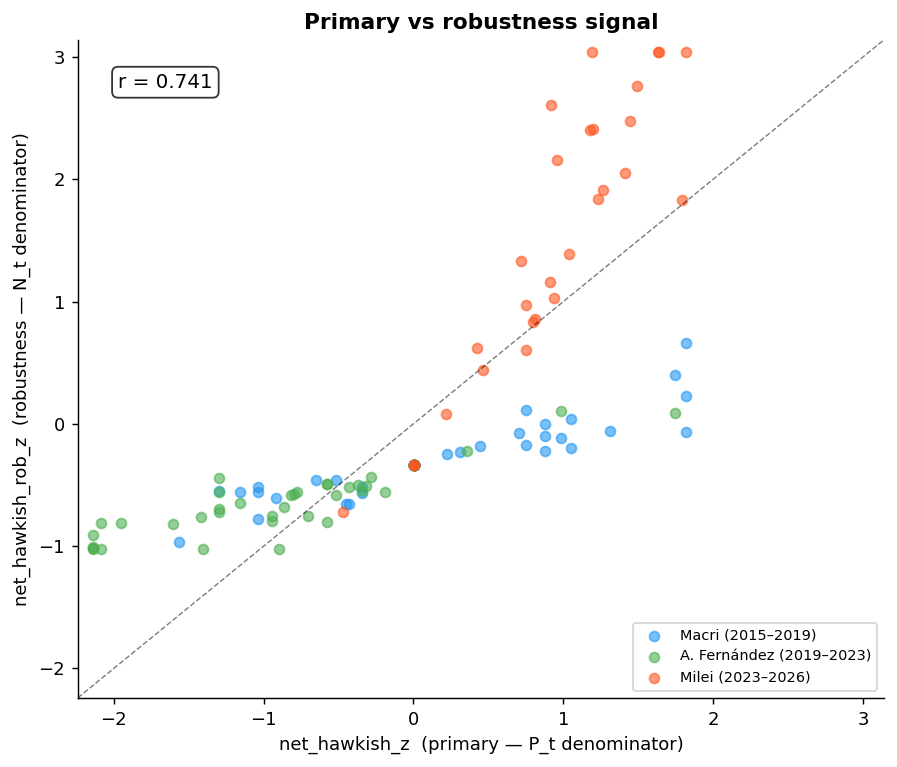

Pearson r: 0.7415


In [24]:
fig, ax = plt.subplots(figsize=(7, 6))
valid = monthly.dropna(subset=["net_hawkish_z","net_hawkish_rob_z"])
for pres in PRES_ORDER:
    g = valid[valid["president"]==pres]
    ax.scatter(g["net_hawkish_z"], g["net_hawkish_rob_z"], c=PRES_COLORS[pres], alpha=0.6, s=30, label=PRES_LABELS[pres])
r = valid["net_hawkish_z"].corr(valid["net_hawkish_rob_z"])
lo = min(valid["net_hawkish_z"].min(), valid["net_hawkish_rob_z"].min()) - 0.1
hi = max(valid["net_hawkish_z"].max(), valid["net_hawkish_rob_z"].max()) + 0.1
ax.plot([lo,hi],[lo,hi],"k--",lw=0.8,alpha=0.5)
ax.text(0.05,0.95,f"r = {r:.3f}",transform=ax.transAxes,fontsize=11,va="top",
        bbox=dict(boxstyle="round",facecolor="white",alpha=0.8))
ax.set_xlabel("net_hawkish_z  (primary — P_t denominator)")
ax.set_ylabel("net_hawkish_rob_z  (robustness — N_t denominator)")
ax.set_title("Primary vs robustness signal", fontsize=12, fontweight="bold")
ax.legend(fontsize=8); ax.set_xlim(lo,hi); ax.set_ylim(lo,hi)
plt.tight_layout(); plt.show()
print(f"Pearson r: {r:.4f}")


## 11. Summary statistics

In [25]:
print("="*75)
print("FISCAL HAWKISHNESS SIGNAL — SUMMARY (v6, EPU-style, winsorised at 2.5/97.5%)")
print("="*75)
print(f"\nDictionary  : 61 hawkish + 46 dovish terms")
print(f"Fiscal filter: fiscal_topic_prob ≥ 0.15  (lda.py k=9 model)")
print(f"Formula      : (H_t − D_t) / P_t, winsorised, z-scored cross-president")

print(f"\n{'Metric':35s}  {'Macri':>10s}  {'AF':>10s}  {'Milei':>10s}")
print("─"*70)
rows = [
    ("N months (non-NaN)", [len(monthly[monthly["president"]==p]["net_hawkish_z"].dropna()) for p in PRES_ORDER]),
    ("Total fiscal paras (P)", [int(monthly[monthly["president"]==p]["n_fiscal_paras"].sum()) for p in PRES_ORDER]),
    ("Mean P_t / month", [f"{monthly[monthly['president']==p]['n_fiscal_paras'].mean():.1f}" for p in PRES_ORDER]),
    ("H_t total", [int(monthly[monthly["president"]==p]["H_t"].sum()) for p in PRES_ORDER]),
    ("D_t total", [int(monthly[monthly["president"]==p]["D_t"].sum()) for p in PRES_ORDER]),
    ("Mean net_hawkish_z", [f"{monthly[monthly['president']==p]['net_hawkish_z'].mean():+.3f}" for p in PRES_ORDER]),
    ("Std  net_hawkish_z", [f"{monthly[monthly['president']==p]['net_hawkish_z'].std():.3f}" for p in PRES_ORDER]),
    ("Max  net_hawkish_z", [f"{monthly[monthly['president']==p]['net_hawkish_z'].max():+.2f}" for p in PRES_ORDER]),
    ("Min  net_hawkish_z", [f"{monthly[monthly['president']==p]['net_hawkish_z'].min():+.2f}" for p in PRES_ORDER]),
]
for label, vals in rows:
    print(f"{label:35s}  {str(vals[0]):>10s}  {str(vals[1]):>10s}  {str(vals[2]):>10s}")

means = {p: monthly[monthly["president"]==p]["net_hawkish_z"].mean() for p in PRES_ORDER}
gap = means["Milei"] - means["AF"]
print(f"\nOrdering  : Milei ({means['Milei']:+.3f}z) > Macri ({means['Macri']:+.3f}z) > AF ({means['AF']:+.3f}z) ✓")
print(f"Milei–AF gap: {gap:.3f}z")
print(f"\nWinsorisation clips: raw max was +2.92z → now +1.82z (r with raw = 0.989)")
print("="*75)


FISCAL HAWKISHNESS SIGNAL — SUMMARY (v6, EPU-style, winsorised at 2.5/97.5%)

Dictionary  : 61 hawkish + 46 dovish terms
Fiscal filter: fiscal_topic_prob ≥ 0.15  (lda.py k=9 model)
Formula      : (H_t − D_t) / P_t, winsorised, z-scored cross-president

Metric                                    Macri          AF       Milei
──────────────────────────────────────────────────────────────────────
N months (non-NaN)                           49          47          29
Total fiscal paras (P)                      478         708        2794
Mean P_t / month                            9.8        14.4        96.3
H_t total                                    47          21         720
D_t total                                    40         124         167
Mean net_hawkish_z                       +0.137      -0.708      +0.915
Std  net_hawkish_z                        0.817       0.857       0.579
Max  net_hawkish_z                        +1.82       +1.75       +1.82
Min  net_hawkish_z          